# KNN Classifier
The k-NN (k-Nearest Neighbors) algorithm is one of the simplest machine learning algorithms.

In KNN, K represents the number of nearest neighbors. The number of neighbors is a key determinant. For a data point to be classified, it finds the k closest neighbor points, then classifies the data based on the majority vote among those k neighbors. To find the most similar points, distance is used.

Advantages: KNN is useful for data with nonlinear classification boundaries.

Disadvantages: It can be slower and more costly in terms of time and memory, especially for high-dimensional data.
![knn](./data/KNN.png)

# Wine Data Classification with KNN

The wine.data dataset provided by scikit-learn contains three types of cultivar classes: 'class_0', 'class_1', and 'class_2'. Create a classification model using the KNN algorithm to classify these classes.

In [8]:
# Import scikit-learn dataset library
from sklearn.datasets import load_wine

wine = load_wine()

# Wine data attributes
print("Wine data attributes (13 features):", wine.feature_names)

# Wine data classes (labels)
print("Wine data classes (3 classes):", wine.target_names)

# Labels (0: Class_0, 1: Class_1, 2: Class_2)
print("Target Labels (0: Class_0, 1: Class_1, 2: Class_2):\n", wine.target)

Wine data attributes (13 features): ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Wine data classes (3 classes): ['class_0' 'class_1' 'class_2']
Target Labels (0: Class_0, 1: Class_1, 2: Class_2):
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [2]:
# Import train_test_split function
from sklearn.model_selection import train_test_split

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.3, random_state=0
)
# 70% training and 30% test

# Choosing the Number of Neighbors (K)
There is no single optimal number of neighbors (K) that works best for all datasets. It’s important to select an appropriate K based on the characteristics of each dataset.

If K is too small:
Noise can have a greater impact on the results. The model will fit more flexibly with low bias but high variance, which can lead to overfitting.

If K is too large:
It can be computationally expensive for large datasets. Increasing K smooths the decision boundary, resulting in lower variance but higher bias, which may cause underfitting.

## K = 3

In [3]:
# Import knearest neighbors Classifier model
from sklearn.neighbors import KNeighborsClassifier

# Create KNN Classifier
knn = KNeighborsClassifier(n_neighbors=3)

# Train the model using the training sets
knn.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = knn.predict(X_test)

In [6]:
# Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

# Model Accuracy, how often is the classifier correct?
print("Accuracy: {:.4f}".format(metrics.accuracy_score(y_test, y_pred)))

Accuracy: 0.7037


## K = 7

In [9]:
# Import knearest neighbors Classifier model
from sklearn.neighbors import KNeighborsClassifier

# Create KNN Classifier
knn = KNeighborsClassifier(n_neighbors=7)

# Train the model using the training sets
knn.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = knn.predict(X_test)

In [10]:
# Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

# Model Accuracy, how often is the classifier correct?
print("Accuracy: {:.4f}".format(metrics.accuracy_score(y_test, y_pred)))

Accuracy: 0.7778


For the wine dataset, the model accuracy improved when K was set to 7.

# Visualization

In [17]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


k_values = range(1, 21)
accuracies = []

for k in k_values:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    scores = cross_val_score(pipe, X, y, cv=5)
    accuracies.append(scores.mean())

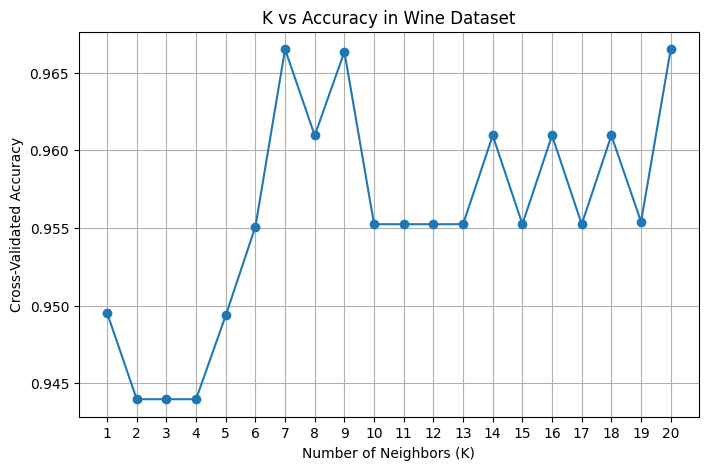

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker="o")
plt.title("K vs Accuracy in Wine Dataset")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Cross-Validated Accuracy")
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Practice

Try increasing or decreasing the number of neighbors K and check how the accuracy changes.

To achieve better results, it is recommended to scale the data to the same scale. Practice standardizing or normalizing the data to improve accuracy.